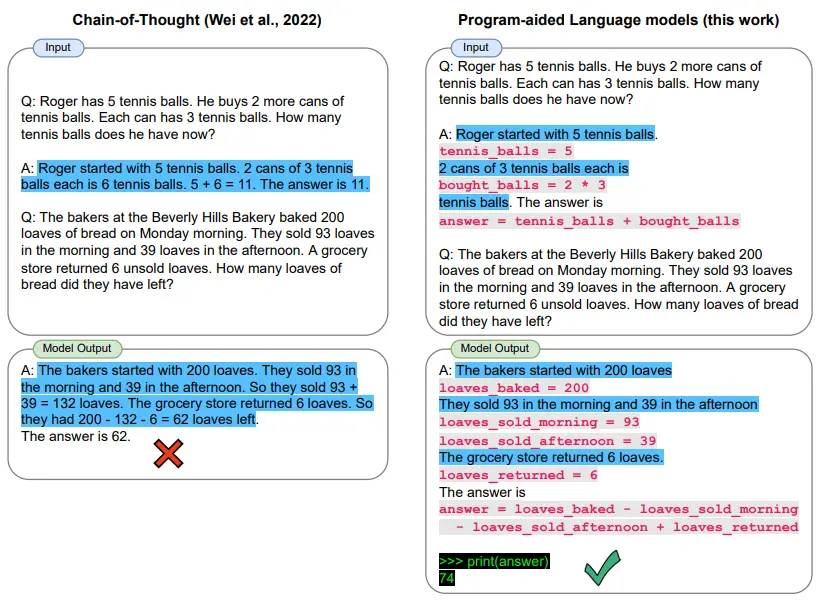

In [7]:
import openai
from datetime import datetime
from dateutil.relativedelta import relativedelta
import os
import re
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv(os.path.join("..", ".env"), override=True)

True

In [3]:
client = OpenAI()

def run_prompt(prompt):
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.3
    )

    return response.choices[0].message.content

In [4]:
question = "Today is 27 February 2023. I was born exactly 25 years ago. What is the date I was born in MM/DD/YYYY?"
 
DATE_UNDERSTANDING_PROMPT = """
# Q: 2015 is coming in 36 hours. What is the date one week from today in MM/DD/YYYY?
# If 2015 is coming in 36 hours, then today is 36 hours before.
today = datetime(2015, 1, 1) - relativedelta(hours=36)
# One week from today,
one_week_from_today = today + relativedelta(weeks=1)
# The answer formatted with %m/%d/%Y is
one_week_from_today.strftime('%m/%d/%Y')
# Q: The first day of 2019 is a Tuesday, and today is the first Monday of 2019. What is the date today in MM/DD/YYYY?
# If the first day of 2019 is a Tuesday, and today is the first Monday of 2019, then today is 6 days later.
today = datetime(2019, 1, 1) + relativedelta(days=6)
# The answer formatted with %m/%d/%Y is
today.strftime('%m/%d/%Y')
# Q: The concert was scheduled to be on 06/01/1943, but was delayed by one day to today. What is the date 10 days ago in MM/DD/YYYY?
# If the concert was scheduled to be on 06/01/1943, but was delayed by one day to today, then today is one day later.
today = datetime(1943, 6, 1) + relativedelta(days=1)
# 10 days ago,
ten_days_ago = today - relativedelta(days=10)
# The answer formatted with %m/%d/%Y is
ten_days_ago.strftime('%m/%d/%Y')
# Q: It is 4/19/1969 today. What is the date 24 hours later in MM/DD/YYYY?
# It is 4/19/1969 today.
today = datetime(1969, 4, 19)
# 24 hours later,
later = today + relativedelta(hours=24)
# The answer formatted with %m/%d/%Y is
today.strftime('%m/%d/%Y')
# Q: Jane thought today is 3/11/2002, but today is in fact Mar 12, which is 1 day later. What is the date 24 hours later in MM/DD/YYYY?
# If Jane thought today is 3/11/2002, but today is in fact Mar 12, then today is 3/12/2002.
today = datetime(2002, 3, 12)
# 24 hours later,
later = today + relativedelta(hours=24)
# The answer formatted with %m/%d/%Y is
later.strftime('%m/%d/%Y')
# Q: Jane was born on the last day of Feburary in 2001. Today is her 16-year-old birthday. What is the date yesterday in MM/DD/YYYY?
# If Jane was born on the last day of Feburary in 2001 and today is her 16-year-old birthday, then today is 16 years later.
today = datetime(2001, 2, 28) + relativedelta(years=16)
# Yesterday,
yesterday = today - relativedelta(days=1)
# The answer formatted with %m/%d/%Y is
yesterday.strftime('%m/%d/%Y')
# Q: {question}
""".strip() + '\n'

In [5]:
out = run_prompt(DATE_UNDERSTANDING_PROMPT.format(question=question))
print(out)

```python
# If today is 27 February 2023, and you were born exactly 25 years ago, then the birth date is 25 years earlier.
today = datetime(2023, 2, 27)
birth_date = today - relativedelta(years=25)
# The answer formatted with %m/%d/%Y is
birth_date.strftime('%m/%d/%Y')
```


In [11]:
pattern = r"```python\s*(.*?)```"
match = re.search(pattern, out, re.DOTALL)
python_code = match.group(1)
print(python_code)

# If today is 27 February 2023, and you were born exactly 25 years ago, then the birth date is 25 years earlier.
today = datetime(2023, 2, 27)
birth_date = today - relativedelta(years=25)
# The answer formatted with %m/%d/%Y is
birth_date.strftime('%m/%d/%Y')



In [14]:
exec(python_code)
print(birth_date)

1998-02-27 00:00:00
